# UK House Price Prediction

Predicts a property's sale price from its type, tenure, floor area, room count, and location, using HM Land Registry Price Paid Data, EPC certificates, and ONS postcode coordinates.

**Files needed in this folder:** `pp-2023.csv`, `pp-2024.csv`, `pp-2025.csv`, `pp-2026.csv`, `epc_extract.csv`, `postcode_lookup.csv`

## Setup

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
import joblib

print("Setup complete")

Setup complete


## Configuration

In [2]:
K = 10                        # nearest neighbours used for the k-NN features
KNN_DIST_SMOOTH_M = 250       # metres — softens the 1/distance weights

SEARCH_SAMPLE_N = 150_000     # rows used for hyperparameter search
SEARCH_N_ITER = 50            # random configurations tried
SEARCH_CV_FOLDS = 3
RANDOM_STATE = 42

## Load Price Paid Data

`PAON`/`SAON`/`Street` are kept for now — needed to match each sale to its EPC record — and dropped once that join is done.

In [3]:
columns = ['TransactionID', 'Price', 'DateOfTransfer', 'Postcode',
           'PropertyType', 'OldNew', 'Duration', 'PAON', 'SAON',
           'Street', 'Locality', 'TownCity', 'District', 'County',
           'PPDCategoryType', 'RecordStatus']

df_2023 = pd.read_csv('pp-2023.csv', header=None); df_2023.columns = columns
df_2024 = pd.read_csv('pp-2024.csv', header=None); df_2024.columns = columns
df_2025 = pd.read_csv('pp-2025.csv', header=None); df_2025.columns = columns

df = pd.concat([df_2023, df_2024, df_2025], ignore_index=True)
print(df.shape)

(2744543, 16)


## Helper Functions

Address matching and spatial lookups are needed for the training data, the test set, and the 2026 validation set, so each one is written once here and reused everywhere.

In [4]:
def normalize_postcode(s):
    """Strip all whitespace and uppercase, so 'SW1A 1AA' and 'sw1a1aa' match."""
    return re.sub(r'\s+', '', str(s)).upper()

def extract_house_number(s):
    """First run of digits in a string, e.g. '12A' -> '12', 'FLATS 12-18' -> '12'."""
    m = re.search(r'\d+', str(s))
    return m.group() if m else ''

def extract_flat_number(s):
    """Looks for 'FLAT n' / 'APARTMENT n' / 'UNIT n' first, else falls back to the first number found."""
    s = str(s)
    m = re.search(r'(?:FLAT|APARTMENT|UNIT)\s*(\d+)', s.upper())
    if m:
        return m.group(1)
    m = re.search(r'\d+', s)
    return m.group() if m else ''

def prep_match_keys(df):
    df = df.copy()
    df['_NormPostcode'] = df['Postcode'].astype(str).str.strip().apply(normalize_postcode)
    df['_HouseNo'] = df['PAON'].apply(extract_house_number)
    df['_FlatNo'] = df['SAON'].apply(extract_flat_number)
    return df

def clean_and_engineer(df):
    """Cleaning, log target, date features, cyclical month, and postcode district,
    plus preparing the address-matching keys used for the EPC join."""
    df['DateOfTransfer'] = pd.to_datetime(df['DateOfTransfer'], format='mixed', dayfirst=True)
    df = df.drop(['RecordStatus'], axis=1)
    df = df[df['Price'] > 1000].copy()
    df['LogPrice'] = np.log(df['Price'])
    df['Year'] = df['DateOfTransfer'].dt.year
    df['Month'] = df['DateOfTransfer'].dt.month
    df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
    df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
    df['Postcode'] = df['Postcode'].fillna('').astype(str).str.strip()
    df['PostcodeOutward'] = df['Postcode'].apply(lambda s: s[:-3].strip() if len(s) > 3 else s)
    df.loc[df['PostcodeOutward'] == '', 'PostcodeOutward'] = 'UNKNOWN'
    return prep_match_keys(df)

def fit_target_encoding(train_series, train_target, smoothing=20):
    global_mean = train_target.mean()
    stats = train_target.groupby(train_series).agg(['mean', 'count'])
    smoothed = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
    return smoothed.to_dict(), global_mean

def apply_target_encoding(series, mapping, global_mean):
    return series.map(mapping).fillna(global_mean)

def mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

def median_ape(actual, predicted):
    return np.median(np.abs((actual - predicted) / actual)) * 100

## Clean & Engineer Base Features

In [5]:
df = clean_and_engineer(df)
print(df.shape)

(2742055, 24)


## Join EPC Data (Floor Area & Room Count)

Matched by postcode + house/flat number. Where a property has several EPC certificates, the one closest in date to the sale is used. Properties with no match keep a missing-value flag instead of being dropped.

In [6]:
# encoding='utf-8-sig' strips a leading BOM character that UK government CSV exports often
# include, which otherwise turns 'POSTCODE' into an invisible '\ufeffPOSTCODE' and breaks
# the column lookup below with a confusing KeyError.
epc = pd.read_csv('epc_extract.csv', encoding='utf-8-sig')
epc.columns = [c.strip() for c in epc.columns]

# Match required columns case-insensitively, since different EPC export tools capitalize
# column headers differently (e.g. 'Postcode' vs 'POSTCODE').
required_epc_cols = ['POSTCODE', 'ADDRESS1', 'ADDRESS2', 'TOTAL_FLOOR_AREA',
                      'NUMBER_HABITABLE_ROOMS', 'LODGEMENT_DATE']
col_map = {c.upper(): c for c in epc.columns}
missing = [r for r in required_epc_cols if r not in col_map]
if missing:
    raise KeyError(
        f"epc_extract.csv is missing expected column(s): {missing}.\n"
        f"Columns actually found in your file: {list(epc.columns)}\n"
        "Rename the matching columns in your EPC extract to these exact names "
        "(or edit 'required_epc_cols' above to match your file's real column names)."
    )
epc = epc.rename(columns={col_map[r]: r for r in required_epc_cols})

epc['_NormPostcode'] = epc['POSTCODE'].apply(normalize_postcode)
epc['_HouseNo'] = epc['ADDRESS1'].apply(extract_house_number)
epc['_FlatNo'] = epc['ADDRESS2'].apply(extract_flat_number)
epc['_LodgementDate'] = pd.to_datetime(epc['LODGEMENT_DATE'], errors='coerce')

epc_lookup = epc[['_NormPostcode', '_HouseNo', '_FlatNo', 'TOTAL_FLOOR_AREA',
                   'NUMBER_HABITABLE_ROOMS', '_LodgementDate']]
print("EPC records loaded:", epc_lookup.shape)

C:\Users\fq5112tu\AppData\Local\Temp\ipykernel_119664\3228775066.py:4: DtypeWarning: Columns (0: floor_energy_eff, 1: floor_env_eff) have mixed types. Specify dtype option on import or set low_memory=False.
  epc = pd.read_csv('epc_extract.csv', encoding='utf-8-sig')


EPC records loaded: (6218241, 6)


In [7]:
def match_epc(df, epc_lookup):
    """Left-join on (postcode, house no, flat no); where several EPC certs match the same
    property, keep the one closest in date to DateOfTransfer. Adds missing-value flags for
    properties with no EPC match at all (kept, not dropped)."""
    df = df.reset_index(drop=True)
    df['_row_id'] = df.index

    merged = df.merge(epc_lookup, on=['_NormPostcode', '_HouseNo', '_FlatNo'], how='left')
    merged['_date_diff'] = (merged['DateOfTransfer'] - merged['_LodgementDate']).abs()
    has_match = merged['_LodgementDate'].notna()

    if has_match.any():
        best_idx = merged[has_match].groupby('_row_id')['_date_diff'].idxmin()
        best_rows = merged.loc[best_idx.values, ['_row_id', 'TOTAL_FLOOR_AREA', 'NUMBER_HABITABLE_ROOMS']]
        best_rows = best_rows.drop_duplicates(subset='_row_id')
        df = df.merge(best_rows, on='_row_id', how='left')
    else:
        df['TOTAL_FLOOR_AREA'] = np.nan
        df['NUMBER_HABITABLE_ROOMS'] = np.nan

    df['FloorArea_missing'] = df['TOTAL_FLOOR_AREA'].isna().astype(int)
    df['Rooms_missing'] = df['NUMBER_HABITABLE_ROOMS'].isna().astype(int)
    return df

df = match_epc(df, epc_lookup)
print(f"EPC match rate: {df['TOTAL_FLOOR_AREA'].notna().mean():.1%}")

EPC match rate: 50.2%


## Join Postcode Coordinates

In [8]:
def geocode(df, geo_lookup):
    return df.merge(geo_lookup, on='_NormPostcode', how='left')

geo = pd.read_csv('postcode_lookup.csv', encoding='utf-8-sig')
geo.columns = [c.strip() for c in geo.columns]

required_geo_cols = ['pcds', 'lat', 'long']
col_map_geo = {c.lower(): c for c in geo.columns}
missing_geo = [r for r in required_geo_cols if r not in col_map_geo]
if missing_geo:
    raise KeyError(
        f"postcode_lookup.csv is missing expected column(s): {missing_geo}.\n"
        f"Columns actually found in your file: {list(geo.columns)}\n"
        "Rename the matching columns (e.g. an ONSPD extract often uses 'pcd'/'pcd2' for the "
        "postcode) to 'pcds', 'lat', 'long', or edit 'required_geo_cols' above."
    )
geo = geo.rename(columns={col_map_geo[r]: r for r in required_geo_cols})

geo['_NormPostcode'] = geo['pcds'].apply(normalize_postcode)
geo_lookup = geo.drop_duplicates(subset='_NormPostcode')[['_NormPostcode', 'lat', 'long']]

df = geocode(df, geo_lookup)
print(f"Geocoding match rate: {df['lat'].notna().mean():.1%}")

# The matching helper columns and raw address fields have done their job -- drop them
df = df.drop(columns=['PAON', 'SAON', 'Street', '_HouseNo', '_FlatNo'])

C:\Users\fq5112tu\AppData\Local\Temp\ipykernel_119664\3704717640.py:4: DtypeWarning: Columns (0: ssr95cd, 1: ruc01ind, 2: ruc11ind, 3: lep21cd2, 4: ruc21ind) have mixed types. Specify dtype option on import or set low_memory=False.
  geo = pd.read_csv('postcode_lookup.csv', encoding='utf-8-sig')


Geocoding match rate: 99.7%


## Train/Test Split

Train on 2023–2024, test on 2025, so evaluation reflects predicting a future, unseen year rather than a random shuffle.

In [9]:
train_mask = df['Year'].isin([2023, 2024])
test_mask = df['Year'] == 2025

train_df = df[train_mask].copy()
test_df = df[test_mask].copy()
print("Train:", train_df.shape, " Test:", test_df.shape)

Train: (1788649, 26)  Test: (953406, 26)


## Fill Missing Floor Area / Room Data

Using the training set's median only, to avoid leaking information from the test or validation sets.

In [10]:
floor_area_median = train_df['TOTAL_FLOOR_AREA'].median()
rooms_median = train_df['NUMBER_HABITABLE_ROOMS'].median()

for d in (train_df, test_df):
    d['TOTAL_FLOOR_AREA'] = d['TOTAL_FLOOR_AREA'].fillna(floor_area_median)
    d['NUMBER_HABITABLE_ROOMS'] = d['NUMBER_HABITABLE_ROOMS'].fillna(rooms_median)

## Encode Postcode District

Each postcode district (e.g. `SW1A`) is replaced by the average sale price in that district, smoothed toward the overall average when a district has few sales, and fit on the training set only.

In [11]:
postcode_map, postcode_global_mean = fit_target_encoding(train_df['PostcodeOutward'], train_df['LogPrice'])

train_df['PostcodeOutward_enc'] = apply_target_encoding(train_df['PostcodeOutward'], postcode_map, postcode_global_mean)
test_df['PostcodeOutward_enc'] = apply_target_encoding(test_df['PostcodeOutward'], postcode_map, postcode_global_mean)

## Spatial Price Feature (Nearest Sales)

For each property, the `K` geographically nearest training sales are found (haversine distance) and used to build two features:

- **`KNN_avg_logprice`** — their distance-weighted average price, so a sale 50 m away counts more than one 2 km away.
- **`KNN_std_logprice`** — how much those nearby prices vary, distinguishing a consistent street from a mixed one.

Each training property excludes itself from its own neighbour average, so it never sees its own price.

In [12]:
EARTH_RADIUS_M = 6_371_000
knn_eps = KNN_DIST_SMOOTH_M / EARTH_RADIUS_M      # haversine distances come back in radians

train_has_geo = train_df['lat'].notna() & train_df['long'].notna()
coords_train_rad = np.radians(train_df.loc[train_has_geo, ['lat', 'long']].values)
logprice_train = train_df.loc[train_has_geo, 'LogPrice'].values
geo_global_mean = train_df['LogPrice'].mean()

nn = NearestNeighbors(n_neighbors=min(K + 1, len(coords_train_rad)), metric='haversine',
                      algorithm='ball_tree', n_jobs=-1)
nn.fit(coords_train_rad)


def weighted_neighbor_stats(neighbor_logprices, neighbor_dists, eps):
    """Inverse-distance-weighted mean and std of the neighbours' LogPrice (one row per property)."""
    w = 1.0 / (neighbor_dists + eps)
    w_sum = w.sum(axis=1)
    mean = (w * neighbor_logprices).sum(axis=1) / w_sum
    var = (w * (neighbor_logprices - mean[:, None]) ** 2).sum(axis=1) / w_sum
    return mean, np.sqrt(var)


def drop_self_neighbors(dist, idx):
    """For training rows queried against their own index: remove each row's own entry so K neighbours
    remain. If a row's own entry is not in the list (many sales sharing one coordinate can crowd it out),
    the farthest neighbour is dropped instead — either way the row never sees its own price."""
    n = idx.shape[0]
    is_self = idx == np.arange(n)[:, None]
    drop_col = np.where(is_self.any(axis=1), is_self.argmax(axis=1), idx.shape[1] - 1)
    keep_mask = np.ones(idx.shape, dtype=bool)
    keep_mask[np.arange(n), drop_col] = False
    return dist[keep_mask].reshape(n, -1), idx[keep_mask].reshape(n, -1)


def apply_knn(target_df, nn_model, coords_train_rad, logprice_train, k, global_mean, global_std, eps):
    """k-NN features for rows that are NOT in the index (test set, 2026 validation)."""
    has_geo = (target_df['lat'].notna() & target_df['long'].notna()).values
    knn_mean = np.full(len(target_df), global_mean)
    knn_std = np.full(len(target_df), global_std)
    if has_geo.sum() > 0:
        coords_q = np.radians(target_df.loc[has_geo, ['lat', 'long']].values)
        dist_q, idx_q = nn_model.kneighbors(coords_q, n_neighbors=min(k, len(coords_train_rad)))
        m, s = weighted_neighbor_stats(logprice_train[idx_q], dist_q, eps)
        knn_mean[has_geo] = m
        knn_std[has_geo] = s
    return knn_mean, knn_std


# leave-one-out for the training set itself
dist_tr, idx_tr = nn.kneighbors(coords_train_rad)
dist_loo, idx_loo = drop_self_neighbors(dist_tr, idx_tr)
knn_mean_loo, knn_std_loo = weighted_neighbor_stats(logprice_train[idx_loo], dist_loo, knn_eps)
del dist_tr, idx_tr, dist_loo, idx_loo      # free memory — these arrays are large on the full dataset

# rows with no coordinates fall back to the training-set average / typical spread
geo_global_std = float(np.median(knn_std_loo)) if len(knn_std_loo) else 0.0
pos = np.where(train_has_geo.values)[0]
knn_mean_full = np.full(len(train_df), geo_global_mean)
knn_std_full = np.full(len(train_df), geo_global_std)
knn_mean_full[pos] = knn_mean_loo
knn_std_full[pos] = knn_std_loo
train_df['KNN_avg_logprice'] = knn_mean_full
train_df['KNN_std_logprice'] = knn_std_full

test_df['KNN_avg_logprice'], test_df['KNN_std_logprice'] = apply_knn(
    test_df, nn, coords_train_rad, logprice_train, K, geo_global_mean, geo_global_std, knn_eps)

print("k-NN features built.  Typical neighbour spread (median std of LogPrice):", round(geo_global_std, 3))

k-NN features built.  Typical neighbour spread (median std of LogPrice): 0.3


## Build Final Feature Matrix

In [13]:
cat_cols = ['PropertyType', 'OldNew', 'Duration']

train_encoded = pd.get_dummies(train_df, columns=cat_cols, drop_first=True)
test_encoded = pd.get_dummies(test_df, columns=cat_cols, drop_first=True)
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

feature_cols = ['PostcodeOutward_enc', 'Month_sin', 'Month_cos', 'Year',
                'TOTAL_FLOOR_AREA', 'NUMBER_HABITABLE_ROOMS', 'FloorArea_missing', 'Rooms_missing',
                'KNN_avg_logprice', 'KNN_std_logprice'] + \
    [c for c in train_encoded.columns if c.startswith(('PropertyType_', 'OldNew_', 'Duration_'))]

X_train = train_encoded[feature_cols]
y_train = train_encoded['LogPrice']
X_test = test_encoded[feature_cols]
y_test = test_encoded['LogPrice']

print("Feature matrix:", X_train.shape, X_test.shape)
print("Features used:", feature_cols)

Feature matrix: (1788649, 16) (953406, 16)
Features used: ['PostcodeOutward_enc', 'Month_sin', 'Month_cos', 'Year', 'TOTAL_FLOOR_AREA', 'NUMBER_HABITABLE_ROOMS', 'FloorArea_missing', 'Rooms_missing', 'KNN_avg_logprice', 'KNN_std_logprice', 'PropertyType_F', 'PropertyType_O', 'PropertyType_S', 'PropertyType_T', 'OldNew_Y', 'Duration_L']


## Hyperparameter Tuning

A random search over XGBoost settings on a data sample, scored by cross-validated MAE, before refitting the best configuration on the full training set.

In [14]:
search_sample_n = min(SEARCH_SAMPLE_N, len(X_train))
sample_idx = X_train.sample(n=search_sample_n, random_state=RANDOM_STATE).index
X_search, y_search = X_train.loc[sample_idx], y_train.loc[sample_idx]

param_dist = {
    'n_estimators': [200, 400, 600, 800, 1000],
    'max_depth': [4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.02, 0.03, 0.05, 0.08, 0.1],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 10, 20],
    'reg_alpha': [0, 0.01, 0.1, 1, 5],          # L1 regularisation
    'reg_lambda': [0.5, 1, 2, 5, 10],          # L2 regularisation
    'gamma': [0, 0.1, 0.5, 1],                 # minimum gain needed to make a split
}

# XGBoost already spreads work across all CPU cores, so the search itself runs one config at a
# time (n_jobs=1) — running both in parallel just makes them fight over the same cores.
base_model = XGBRegressor(tree_method='hist', n_jobs=-1, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    base_model, param_distributions=param_dist, n_iter=SEARCH_N_ITER,
    cv=KFold(n_splits=SEARCH_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_mean_absolute_error', random_state=RANDOM_STATE, n_jobs=1, verbose=2
)
search.fit(X_search, y_search)
print("Best params:", search.best_params_)
print("Best cross-validated MAE (log scale):", round(-search.best_score_, 4))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END colsample_bytree=0.9, gamma=1, learning_rate=0.05, max_depth=6, min_child_weight=10, n_estimators=400, reg_alpha=5, reg_lambda=5, subsample=0.9; total time=   4.2s
[CV] END colsample_bytree=0.9, gamma=1, learning_rate=0.05, max_depth=6, min_child_weight=10, n_estimators=400, reg_alpha=5, reg_lambda=5, subsample=0.9; total time=   4.7s
[CV] END colsample_bytree=0.9, gamma=1, learning_rate=0.05, max_depth=6, min_child_weight=10, n_estimators=400, reg_alpha=5, reg_lambda=5, subsample=0.9; total time=   4.9s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.02, max_depth=4, min_child_weight=3, n_estimators=600, reg_alpha=0, reg_lambda=5, subsample=0.9; total time=   5.8s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.02, max_depth=4, min_child_weight=3, n_estimators=600, reg_alpha=0, reg_lambda=5, subsample=0.9; total time=   4.2s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.02, max_depth

## Train Final Model

In [15]:
final_model = XGBRegressor(tree_method='hist', n_jobs=-1, random_state=RANDOM_STATE, **search.best_params_)
final_model.fit(X_train, y_train)
print("Final model trained on", X_train.shape[0], "rows")

Final model trained on 1788649 rows


## Evaluate on the Test Set

In [16]:
y_pred = final_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae_log = mean_absolute_error(y_test, y_pred)
actual_price = np.exp(y_test)
predicted_price = np.exp(y_pred)
mae_price = mean_absolute_error(actual_price, predicted_price)

print(f"R²: {r2:.4f}")
print(f"MAE (log scale): {mae_log:.4f}")
print(f"MAE (£): £{mae_price:,.0f}")
print(f"MAPE: {mape(actual_price, predicted_price):.2f}%")
print(f"Median APE: {median_ape(actual_price, predicted_price):.2f}%")

R²: 0.6554
MAE (log scale): 0.2466
MAE (£): £112,380
MAPE: 43.26%
Median APE: 15.66%


## Feature Importance

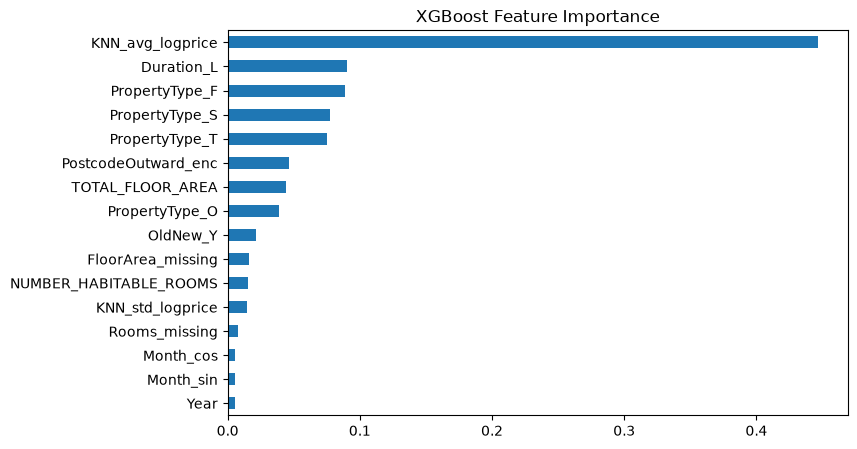

KNN_avg_logprice          0.446698
Duration_L                0.090152
PropertyType_F            0.088970
PropertyType_S            0.077099
PropertyType_T            0.074867
PostcodeOutward_enc       0.046155
TOTAL_FLOOR_AREA          0.043795
PropertyType_O            0.039022
OldNew_Y                  0.021779
FloorArea_missing         0.016334
NUMBER_HABITABLE_ROOMS    0.015032
KNN_std_logprice          0.014511
Rooms_missing             0.008135
Month_cos                 0.005872
Month_sin                 0.005832
Year                      0.005746
dtype: float32

In [17]:
importances = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.plot(kind='barh')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.show()

importances

## Model Explainability (SHAP)

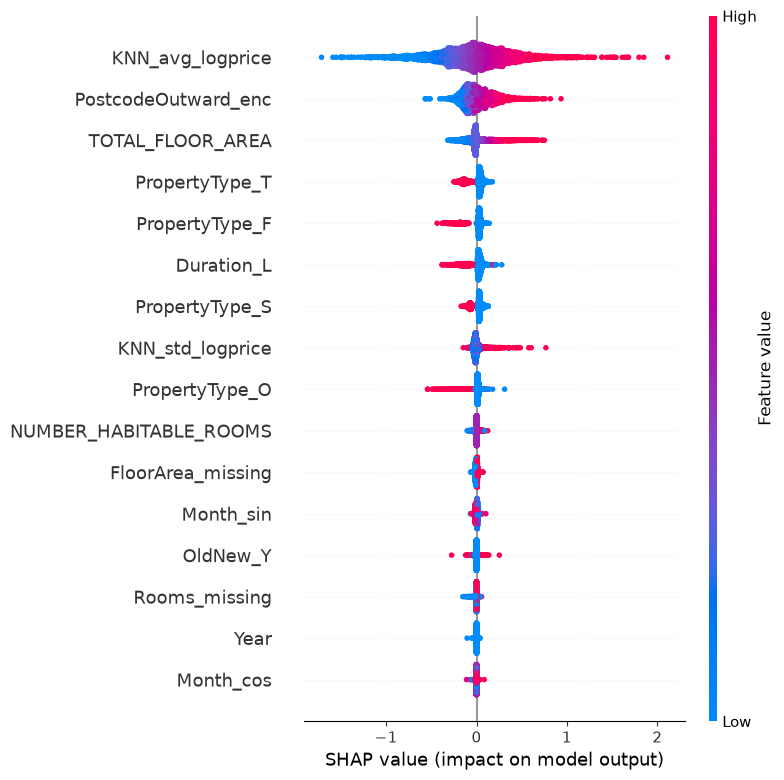

In [18]:
import shap

X_sample = X_test.sample(n=min(5000, len(X_test)), random_state=42)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

## Validate on 2026 Sales (Unseen Data)

The helper functions and objects fit above are reused as-is — nothing is refit here — so this is a genuine test on data the model has never seen.

In [19]:
df_2026 = pd.read_csv('pp-2026.csv', header=None)
df_2026.columns = columns

df_2026 = clean_and_engineer(df_2026)
df_2026 = match_epc(df_2026, epc_lookup)
df_2026 = geocode(df_2026, geo_lookup)

df_2026['TOTAL_FLOOR_AREA'] = df_2026['TOTAL_FLOOR_AREA'].fillna(floor_area_median)
df_2026['NUMBER_HABITABLE_ROOMS'] = df_2026['NUMBER_HABITABLE_ROOMS'].fillna(rooms_median)
df_2026['PostcodeOutward_enc'] = apply_target_encoding(df_2026['PostcodeOutward'], postcode_map, postcode_global_mean)
df_2026['KNN_avg_logprice'], df_2026['KNN_std_logprice'] = apply_knn(
    df_2026, nn, coords_train_rad, logprice_train, K, geo_global_mean, geo_global_std, knn_eps)

In [20]:
val_encoded = pd.get_dummies(df_2026, columns=cat_cols, drop_first=True)
val_encoded = val_encoded.reindex(columns=train_encoded.columns, fill_value=0)
X_val = val_encoded[feature_cols]

val_pred_price = np.exp(final_model.predict(X_val))

val_mae = mean_absolute_error(df_2026['Price'], val_pred_price)
val_mape = mape(df_2026['Price'].values, val_pred_price)
val_median_ape = median_ape(df_2026['Price'].values, val_pred_price)

print(f"2026 validation (all counties) MAE (£): £{val_mae:,.0f}")
print(f"2026 validation MAPE: {val_mape:.2f}%")
print(f"2026 validation Median APE: {val_median_ape:.2f}%")

2026 validation (all counties) MAE (£): £88,978
2026 validation MAPE: 29.45%
2026 validation Median APE: 15.76%


### Example: Surrey Detached Homes, June

In [21]:
surrey_subset = df_2026[
    (df_2026['County'].str.upper() == 'SURREY') &
    (df_2026['PropertyType'] == 'D') &
    (df_2026['OldNew'] == 'N') &
    (df_2026['Duration'] == 'F') &
    (df_2026['Month'] == 6)
].copy()

print("Matching real sales found:", len(surrey_subset))

if len(surrey_subset) > 0:
    surrey_encoded = pd.get_dummies(surrey_subset, columns=cat_cols, drop_first=True)
    surrey_encoded = surrey_encoded.reindex(columns=train_encoded.columns, fill_value=0)
    X_surrey = surrey_encoded[feature_cols]

    surrey_pred_price = np.exp(final_model.predict(X_surrey))
    surrey_mae = mean_absolute_error(surrey_subset['Price'], surrey_pred_price)
    surrey_mape = mape(surrey_subset['Price'].values, surrey_pred_price)

    print(f"MAE: £{surrey_mae:,.0f} | MAPE: {surrey_mape:.2f}%")

Matching real sales found: 236
MAE: £647,122 | MAPE: 18.76%


## Save the Model

In [22]:
joblib.dump(final_model, 'xgb_model.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')
print("Saved xgb_model.pkl and feature_cols.pkl")

Saved xgb_model.pkl and feature_cols.pkl


## Live Prediction Demo

Run the cell below, then type in a property's details when prompted. It uses the model and lookups already fit above — nothing is retrained. The result is shown as a predicted price plus a likely range, based on the model's average error on the test set.


In [ ]:
def predict_price_live(postcode, property_type, old_new, duration, floor_area, rooms, year, month):
    
    postcode = str(postcode).strip()
    norm_pc = normalize_postcode(postcode)
    outward = postcode[:-3].strip() if len(postcode) > 3 else postcode
    if outward == '':
        outward = 'UNKNOWN'

    geo_match = geo_lookup[geo_lookup['_NormPostcode'] == norm_pc]
    lat = geo_match['lat'].iloc[0] if len(geo_match) else np.nan
    long = geo_match['long'].iloc[0] if len(geo_match) else np.nan

    row = pd.DataFrame(0, index=[0], columns=feature_cols)
    row['Year'] = year
    row['Month_sin'] = np.sin(2 * np.pi * month / 12)
    row['Month_cos'] = np.cos(2 * np.pi * month / 12)

    has_area = floor_area is not None and floor_area > 0
    has_rooms = rooms is not None and rooms > 0
    row['TOTAL_FLOOR_AREA'] = floor_area if has_area else floor_area_median
    row['NUMBER_HABITABLE_ROOMS'] = rooms if has_rooms else rooms_median
    row['FloorArea_missing'] = 0 if has_area else 1
    row['Rooms_missing'] = 0 if has_rooms else 1

    row['PostcodeOutward_enc'] = apply_target_encoding(
        pd.Series([outward]), postcode_map, postcode_global_mean).iloc[0]

    geo_row = pd.DataFrame({'lat': [lat], 'long': [long]})
    knn_mean, knn_std = apply_knn(geo_row, nn, coords_train_rad, logprice_train,
                                   K, geo_global_mean, geo_global_std, knn_eps)
    row['KNN_avg_logprice'] = knn_mean[0]
    row['KNN_std_logprice'] = knn_std[0]

    for col, value in [('PropertyType', property_type), ('OldNew', old_new), ('Duration', duration)]:
        dummy_col = f'{col}_{value}'
        if dummy_col in row.columns:
            row[dummy_col] = 1

    predicted_price = float(np.exp(final_model.predict(row[feature_cols])[0]))
    location_note = "postcode matched" if len(geo_match) else "postcode not found — using area-average location signal"
    return predicted_price, location_note

In [28]:
print("Enter the property details to get a predicted price.\n")

type = input("Property Type - D=Detached, S=Semi-detached, T=Terraced, F=Flat, O=Other: ").strip().upper()
new_build = input("New build? - Y=Yes, N=No: ").strip().upper()
tenure = input("Tenure - F=Freehold, L=Leasehold: ").strip().upper()
zipcode = input("Postcode, e.g. GU1 3AB: ").strip().upper()
floor_area_raw = input("Floor area in m^2 (press Enter if unknown): ").strip()
rooms_raw = input("Number of rooms (press Enter if unknown): ").strip()
year_raw = input("Year of sale (press Enter for 2026): ").strip()
month_raw = input("Month of sale, 1-12 (press Enter for 6): ").strip()

floor_area = float(floor_area_raw) if floor_area_raw else None
rooms = int(rooms_raw) if rooms_raw else None
year = int(year_raw) if year_raw else 2026
month = int(month_raw) if month_raw else 6

predicted_price, location_note = predict_price_live(
    zipcode, type, new_build, tenure, floor_area, rooms, year, month)

margin = mae_price  # the model's average £ error, measured earlier on the test set
low, high = predicted_price - margin, predicted_price + margin

print(f"\nPredicted price: £{predicted_price:,.0f}")
print(f"Likely range: £{low:,.0f} - £{high:,.0f}  (based on the model's average error of ±£{margin:,.0f})")
print(f"Location note: {location_note}")


Enter the property details to get a predicted price.


Predicted price: £220,078
Likely range: £107,698 - £332,457  (based on the model's average error of ±£112,380)
Location note: postcode matched


## Export for Power BI

Writes one CSV of the cleaned transaction data — for building analytics charts (price trends, regional comparisons, property type breakdowns) in Power BI. This is the underlying dataset only, not model predictions.


In [25]:
import os
os.makedirs('powerbi_export', exist_ok=True)

analytics_cols = ['Year', 'Month', 'County', 'TownCity', 'PostcodeOutward',
                   'PropertyType', 'OldNew', 'Duration', 'Price']
df[analytics_cols].to_csv('powerbi_export/house_price_analytics.csv', index=False)

print("Exported", len(df), "rows to", os.path.abspath('powerbi_export/house_price_analytics.csv'))


Exported 2742055 rows to c:\Price_Prediction_Project\powerbi_export\house_price_analytics.csv
